In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── 1. Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv(
    r'C:\Users\Max\Documents\anaconda_projects\EVOO\EVOO_Prices_Bari.csv',
    parse_dates=['date'],
    dayfirst=False          # dates are YYYY-MM-DD so this is fine
)

print(df.shape)
print(df.dtypes)
print(df.head(10))

(289, 4)
date     datetime64[ns]
min             float64
max             float64
notes            object
dtype: object
        date  min  max    notes
0 2026-03-10  6.9  7.4      NaN
1 2026-03-03  6.9  7.4      NaN
2 2026-02-24  6.8  7.4      NaN
3 2026-02-17  6.8  7.4      NaN
4 2026-02-10  6.8  7.4      NaN
5 2026-02-03  6.8  7.4      NaN
6 2026-01-27  6.8  7.4      NaN
7 2026-01-20  6.8  7.4      NaN
8 2026-01-13  6.8  7.4      NaN
9 2026-01-06  NaN  NaN  holiday


In [2]:
# ── 2. Compute midpoint and target variable ───────────────────────────────
df = df.sort_values('date').reset_index(drop=True)

df['midpoint'] = (df['min'] + df['max']) / 2

df['pct_change'] = df['midpoint'].pct_change() * 100

print(df[['date', 'min', 'max', 'midpoint', 'pct_change']].head(20))
print(f"\nTotal rows: {len(df)}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nMissing midpoints: {df['midpoint'].isna().sum()}")
print(f"Missing pct_change: {df['pct_change'].isna().sum()}")

         date  min  max  midpoint  pct_change
0  2020-09-01  3.7  3.9      3.80         NaN
1  2020-09-08  3.7  3.9      3.80    0.000000
2  2020-09-15  3.7  3.9      3.80    0.000000
3  2020-09-22  3.8  4.0      3.90    2.631579
4  2020-09-29  3.8  4.0      3.90    0.000000
5  2020-10-06  4.0  4.1      4.05    3.846154
6  2020-10-13  4.8  5.0      4.90   20.987654
7  2020-10-20  4.8  5.0      4.90    0.000000
8  2020-10-27  5.0  5.2      5.10    4.081633
9  2020-11-03  4.6  4.9      4.75   -6.862745
10 2020-11-10  4.6  4.9      4.75    0.000000
11 2020-11-17  4.6  4.9      4.75    0.000000
12 2020-11-24  4.7  4.9      4.80    1.052632
13 2020-12-01  4.7  4.9      4.80    0.000000
14 2020-12-08  NaN  NaN       NaN    0.000000
15 2020-12-15  4.7  4.9      4.80    0.000000
16 2020-12-22  4.7  4.9      4.80    0.000000
17 2020-12-29  4.7  4.9      4.80    0.000000
18 2021-01-05  NaN  NaN       NaN    0.000000
19 2021-01-12  4.7  4.9      4.80    0.000000

Total rows: 289

Date range: 2020

C:\Users\Max\AppData\Local\Temp\ipykernel_10620\2373640439.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['pct_change'] = df['midpoint'].pct_change() * 100


In [3]:
# ── 3. Inspect missing values ─────────────────────────────────────────────
missing = df[df['midpoint'].isna()]
print(f"Total missing: {len(missing)}")
print(missing[['date', 'min', 'max', 'midpoint', 'notes']])

Total missing: 36
          date  min  max  midpoint        notes
14  2020-12-08  NaN  NaN       NaN          NaN
18  2021-01-05  NaN  NaN       NaN          NaN
31  2021-04-06  NaN  NaN       NaN          NaN
49  2021-08-10  NaN  NaN       NaN          NaN
50  2021-08-17  NaN  NaN       NaN          NaN
69  2021-12-28  NaN  NaN       NaN          NaN
70  2022-01-04  NaN  NaN       NaN          NaN
85  2022-04-19  NaN  NaN       NaN          NaN
88  2022-05-10  NaN  NaN       NaN          NaN
101 2022-08-09  NaN  NaN       NaN          NaN
102 2022-08-16  NaN  NaN       NaN          NaN
113 2022-11-01  NaN  NaN       NaN          NaN
121 2022-12-27  NaN  NaN       NaN          NaN
122 2023-01-03  NaN  NaN       NaN          NaN
136 2023-04-11  NaN  NaN       NaN          NaN
138 2023-04-25  NaN  NaN       NaN          NaN
140 2023-05-09  NaN  NaN       NaN          NaN
149 2023-07-11  8.0  NaN       NaN  Max missing
150 2023-07-18  8.7  NaN       NaN  Max missing
154 2023-08-15  NaN  N

In [4]:
df.loc[df['date'] == '2024-11-12', 'notes'] = 'no publication - reason unknown'

In [5]:
# ── 4. Impute missing values ──────────────────────────────────────────────

# Fix for FutureWarning - cast strings to datetime explicitly
target_dates = pd.to_datetime(['2023-07-11', '2023-07-18'])

df.loc[df['date'].isin(target_dates), 'midpoint'] = \
    df.loc[df['date'].isin(target_dates), 'min']

df.loc[df['date'].isin(target_dates), 'notes'] = \
    'midpoint imputed from min (max missing)'

# For all other NaN midpoints: forward fill
# (price didn't change, market just didn't publish)
df['midpoint'] = df['midpoint'].ffill()

# Recompute pct_change after imputation
df['pct_change'] = df['midpoint'].pct_change() * 100

print(f"Missing midpoints after imputation: {df['midpoint'].isna().sum()}")
print(f"Missing pct_change after imputation: {df['pct_change'].isna().sum()}")

Missing midpoints after imputation: 0
Missing pct_change after imputation: 1


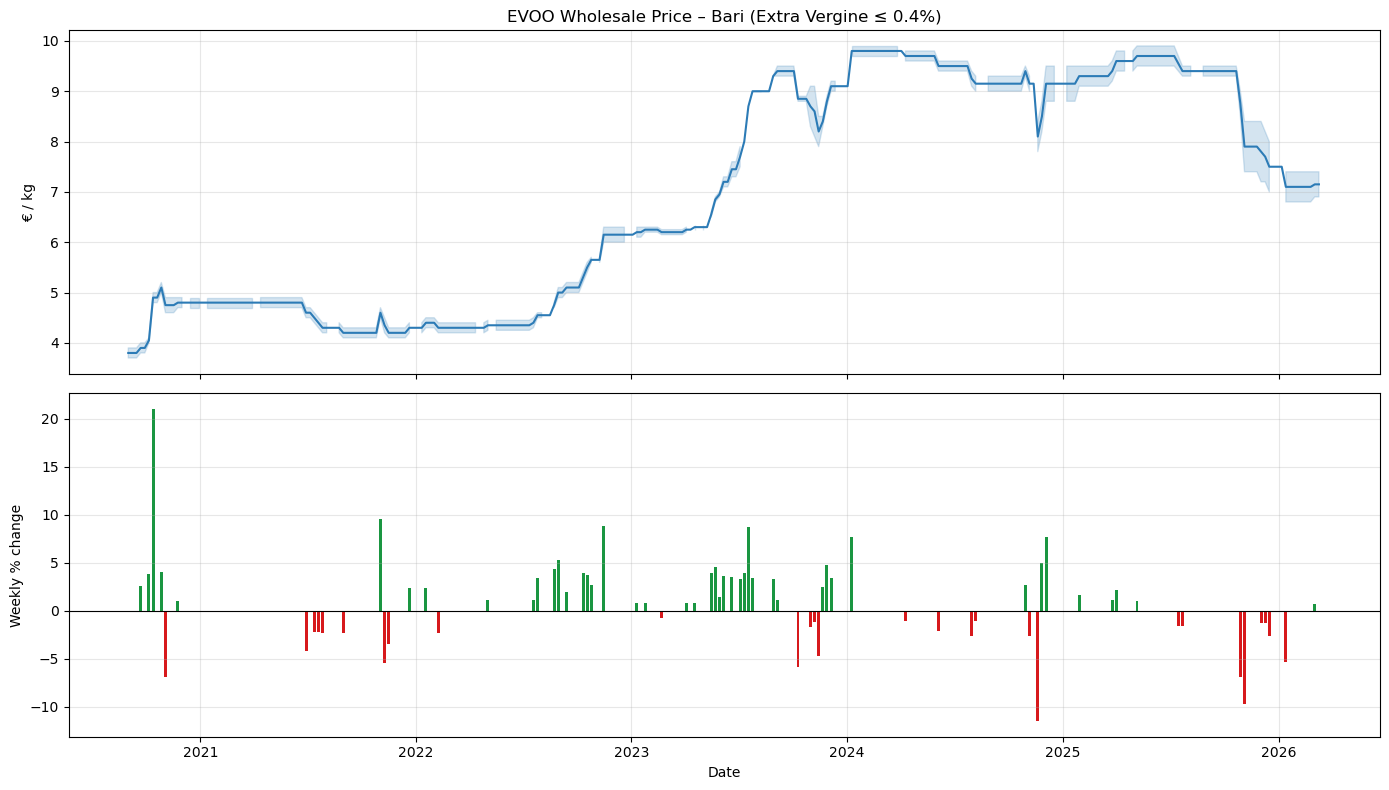

In [6]:
# ── 5. First time series chart ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: price level
ax1.plot(df['date'], df['midpoint'], color='#2c7bb6', linewidth=1.5)
ax1.fill_between(df['date'], df['min'], df['max'], alpha=0.2, color='#2c7bb6')
ax1.set_ylabel('€ / kg')
ax1.set_title('EVOO Wholesale Price – Bari (Extra Vergine ≤ 0.4%)')
ax1.grid(True, alpha=0.3)

# Bottom panel: weekly % change
ax2.bar(df['date'], df['pct_change'], color=df['pct_change'].apply(
    lambda x: '#d7191c' if x < 0 else '#1a9641'), width=5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Weekly % change')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\Max\Documents\anaconda_projects\EVOO\price_series.png', dpi=150)
plt.show()

In [7]:
# ── 6. Summary statistics ─────────────────────────────────────────────────
print(df[['min', 'max', 'midpoint', 'pct_change']].describe().round(3))

           min      max  midpoint  pct_change
count  255.000  253.000   289.000     288.000
mean     6.824    7.087     6.965       0.248
std      2.197    2.255     2.204       2.411
min      3.700    3.900     3.800     -11.475
25%      4.700    4.900     4.800       0.000
50%      6.800    7.000     7.100       0.000
75%      9.100    9.500     9.300       0.000
max      9.700    9.900     9.800      20.988


In [8]:
# ── 7. Build autoregressive features ─────────────────────────────────────

# Lags of the target variable (pct_change)
lags = [1, 2, 3, 4, 8]

for lag in lags:
    df[f'lag_{lag}'] = df['pct_change'].shift(lag)

# Seasonality features
# Week of year captures annual harvest cycle
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# A simple harvest season flag: Oct-Nov is when new oil hits the market
df['harvest_season'] = df['date'].dt.month.isin([10, 11]).astype(int)

# Check what we've built
feature_cols = [f'lag_{l}' for l in lags] + ['week_of_year', 'harvest_season']
print(df[['date', 'pct_change'] + feature_cols].head(20))
print(f"\nNaN rows after feature creation: {df[feature_cols].isna().any(axis=1).sum()}")

         date  pct_change      lag_1      lag_2      lag_3      lag_4  \
0  2020-09-01         NaN        NaN        NaN        NaN        NaN   
1  2020-09-08    0.000000        NaN        NaN        NaN        NaN   
2  2020-09-15    0.000000   0.000000        NaN        NaN        NaN   
3  2020-09-22    2.631579   0.000000   0.000000        NaN        NaN   
4  2020-09-29    0.000000   2.631579   0.000000   0.000000        NaN   
5  2020-10-06    3.846154   0.000000   2.631579   0.000000   0.000000   
6  2020-10-13   20.987654   3.846154   0.000000   2.631579   0.000000   
7  2020-10-20    0.000000  20.987654   3.846154   0.000000   2.631579   
8  2020-10-27    4.081633   0.000000  20.987654   3.846154   0.000000   
9  2020-11-03   -6.862745   4.081633   0.000000  20.987654   3.846154   
10 2020-11-10    0.000000  -6.862745   4.081633   0.000000  20.987654   
11 2020-11-17    0.000000   0.000000  -6.862745   4.081633   0.000000   
12 2020-11-24    1.052632   0.000000   0.000000  -6

In [9]:
# ── 8. Train/test split and baseline model ────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Drop rows with any NaN in features or target
model_df = df[['date', 'pct_change'] + feature_cols].dropna().copy()

# Define horizons
horizons = [1, 2, 4, 8]

# Split date
split_date = '2024-01-01'

results = {}

for h in horizons:
    # Create horizon-specific target: pct_change h weeks ahead
    model_df[f'target_{h}'] = model_df['pct_change'].shift(-h)
    
    # Drop rows where target is NaN (end of series)
    horizon_df = model_df.dropna(subset=[f'target_{h}'])
    
    # Split
    train = horizon_df[horizon_df['date'] < split_date]
    test  = horizon_df[horizon_df['date'] >= split_date]
    
    X_train = train[feature_cols]
    y_train = train[f'target_{h}']
    X_test  = test[feature_cols]
    y_test  = test[f'target_{h}']
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Naive baseline: always predict zero
    y_naive = np.zeros(len(y_test))
    
    # Metrics
    mae_model  = mean_absolute_error(y_test, y_pred)
    mae_naive  = mean_absolute_error(y_test, y_naive)
    rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))
    
    # Directional accuracy
    dir_model = np.mean(np.sign(y_pred) == np.sign(y_test)) * 100
    dir_naive = np.mean(np.sign(y_naive) == np.sign(y_test)) * 100
    
    results[h] = {
        'mae_model':  round(mae_model, 3),
        'mae_naive':  round(mae_naive, 3),
        'rmse_model': round(rmse_model, 3),
        'rmse_naive': round(rmse_naive, 3),
        'dir_model':  round(dir_model, 1),
        'dir_naive':  round(dir_naive, 1),
        'train_rows': len(train),
        'test_rows':  len(test)
    }

# Print results table
print(f"{'Horizon':<10} {'MAE model':<12} {'MAE naive':<12} {'RMSE model':<12} {'RMSE naive':<12} {'Dir% model':<12} {'Dir% naive'}")
print("-" * 85)
for h, r in results.items():
    print(f"{h:<10} {r['mae_model']:<12} {r['mae_naive']:<12} {r['rmse_model']:<12} {r['rmse_naive']:<12} {r['dir_model']:<12} {r['dir_naive']}")

print(f"\nTrain rows: {results[1]['train_rows']} | Test rows: {results[1]['test_rows']}")

Horizon    MAE model    MAE naive    RMSE model   RMSE naive   Dir% model   Dir% naive
-------------------------------------------------------------------------------------
1          0.938        0.708        2.14         2.088        9.6          79.8
2          0.917        0.647        2.043        1.969        9.7          80.5
4          0.927        0.658        2.046        1.986        9.0          80.2
8          1.054        0.683        2.126        2.023        7.5          79.4

Train rows: 165 | Test rows: 114


In [10]:
# ── 9. Improved baseline: add price level + scale features ────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Add price level as a feature (captures mean reversion)
df['midpoint_zscore'] = (df['midpoint'] - df['midpoint'].rolling(52).mean()) / \
                         df['midpoint'].rolling(52).std()

# Updated feature list
feature_cols_v2 = [f'lag_{l}' for l in lags] + \
                  ['week_of_year', 'harvest_season', 'midpoint_zscore']

# Rebuild model_df with new feature
model_df_v2 = df[['date', 'pct_change'] + feature_cols_v2].dropna().copy()

results_v2 = {}

for h in horizons:
    model_df_v2[f'target_{h}'] = model_df_v2['pct_change'].shift(-h)
    horizon_df = model_df_v2.dropna(subset=[f'target_{h}'])

    train = horizon_df[horizon_df['date'] < split_date]
    test  = horizon_df[horizon_df['date'] >= split_date]

    X_train = train[feature_cols_v2]
    y_train = train[f'target_{h}']
    X_test  = test[feature_cols_v2]
    y_test  = test[f'target_{h}']

    # Pipeline: scale then regress
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_naive = np.zeros(len(y_test))

    mae_model  = mean_absolute_error(y_test, y_pred)
    mae_naive  = mean_absolute_error(y_test, y_naive)
    rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))
    dir_model  = np.mean(np.sign(y_pred) == np.sign(y_test)) * 100
    dir_naive  = np.mean(np.sign(y_naive) == np.sign(y_test)) * 100

    results_v2[h] = {
        'mae_model':  round(mae_model, 3),
        'mae_naive':  round(mae_naive, 3),
        'rmse_model': round(rmse_model, 3),
        'rmse_naive': round(rmse_naive, 3),
        'dir_model':  round(dir_model, 1),
        'dir_naive':  round(dir_naive, 1),
    }

print(f"{'Horizon':<10} {'MAE model':<12} {'MAE naive':<12} {'RMSE model':<12} {'RMSE naive':<12} {'Dir% model':<12} {'Dir% naive'}")
print("-" * 85)
for h, r in results_v2.items():
    print(f"{h:<10} {r['mae_model']:<12} {r['mae_naive']:<12} {r['rmse_model']:<12} {r['rmse_naive']:<12} {r['dir_model']:<12} {r['dir_naive']}")

Horizon    MAE model    MAE naive    RMSE model   RMSE naive   Dir% model   Dir% naive
-------------------------------------------------------------------------------------
1          1.066        0.708        2.127        2.088        9.6          79.8
2          1.078        0.647        2.11         1.969        8.0          80.5
4          1.093        0.658        2.102        1.986        8.1          80.2
8          1.319        0.683        2.271        2.023        6.5          79.4


In [11]:
# ── 10. Random Forest model ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# We reuse feature_cols_v2 and model_df_v2 from the previous cell
# but let's go back to the simpler feature set first
# (midpoint_zscore stays as it may help tree-based models)

results_rf = {}

for h in horizons:
    model_df_v2[f'target_{h}'] = model_df_v2['pct_change'].shift(-h)
    horizon_df = model_df_v2.dropna(subset=[f'target_{h}'])

    train = horizon_df[horizon_df['date'] < split_date]
    test  = horizon_df[horizon_df['date'] >= split_date]

    X_train = train[feature_cols_v2]
    y_train = train[f'target_{h}']
    X_test  = test[feature_cols_v2]
    y_test  = test[f'target_{h}']

    # Random Forest
    # n_estimators: number of trees
    # max_depth: limits tree depth to avoid overfitting on small dataset
    # random_state: reproducibility
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=5,
        random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred  = rf.predict(X_test)
    y_naive = np.zeros(len(y_test))

    mae_model  = mean_absolute_error(y_test, y_pred)
    mae_naive  = mean_absolute_error(y_test, y_naive)
    rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))
    dir_model  = np.mean(np.sign(y_pred) == np.sign(y_test)) * 100
    dir_naive  = np.mean(np.sign(y_naive) == np.sign(y_test)) * 100

    results_rf[h] = {
        'mae_model':  round(mae_model, 3),
        'mae_naive':  round(mae_naive, 3),
        'rmse_model': round(rmse_model, 3),
        'rmse_naive': round(rmse_naive, 3),
        'dir_model':  round(dir_model, 1),
        'dir_naive':  round(dir_naive, 1),
    }

    # Feature importance for 1-week horizon
    if h == 1:
        importances = pd.Series(rf.feature_importances_, index=feature_cols_v2)
        print("Feature importances (1-week horizon):")
        print(importances.sort_values(ascending=False).round(3))
        print()

print(f"{'Horizon':<10} {'MAE model':<12} {'MAE naive':<12} {'RMSE model':<12} {'RMSE naive':<12} {'Dir% model':<12} {'Dir% naive'}")
print("-" * 85)
for h, r in results_rf.items():
    print(f"{h:<10} {r['mae_model']:<12} {r['mae_naive']:<12} {r['rmse_model']:<12} {r['rmse_naive']:<12} {r['dir_model']:<12} {r['dir_naive']}")

Feature importances (1-week horizon):
midpoint_zscore    0.291
week_of_year       0.192
lag_4              0.157
lag_8              0.100
lag_3              0.099
lag_1              0.065
harvest_season     0.057
lag_2              0.039
dtype: float64

Horizon    MAE model    MAE naive    RMSE model   RMSE naive   Dir% model   Dir% naive
-------------------------------------------------------------------------------------
1          1.044        0.708        2.069        2.088        10.5         79.8
2          1.075        0.647        2.045        1.969        8.0          80.5
4          1.024        0.658        2.043        1.986        9.0          80.2
8          1.634        0.683        2.457        2.023        8.4          79.4


In [12]:
# ── 11. Gradient Boosting model ───────────────────────────────────────────
from sklearn.ensemble import GradientBoostingRegressor

results_gb = {}

for h in horizons:
    model_df_v2[f'target_{h}'] = model_df_v2['pct_change'].shift(-h)
    horizon_df = model_df_v2.dropna(subset=[f'target_{h}'])

    train = horizon_df[horizon_df['date'] < split_date]
    test  = horizon_df[horizon_df['date'] >= split_date]

    X_train = train[feature_cols_v2]
    y_train = train[f'target_{h}']
    X_test  = test[feature_cols_v2]
    y_test  = test[f'target_{h}']

    gb = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=3,        # shallower than RF - GB is more sensitive to depth
        learning_rate=0.05, # slow learning rate reduces overfitting
        min_samples_leaf=5,
        subsample=0.8,      # use 80% of data per tree - adds robustness
        random_state=42
    )

    gb.fit(X_train, y_train)
    y_pred  = gb.predict(X_test)
    y_naive = np.zeros(len(y_test))

    mae_model  = mean_absolute_error(y_test, y_pred)
    mae_naive  = mean_absolute_error(y_test, y_naive)
    rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))
    dir_model  = np.mean(np.sign(y_pred) == np.sign(y_test)) * 100
    dir_naive  = np.mean(np.sign(y_naive) == np.sign(y_test)) * 100

    results_gb[h] = {
        'mae_model':  round(mae_model, 3),
        'mae_naive':  round(mae_naive, 3),
        'rmse_model': round(rmse_model, 3),
        'rmse_naive': round(rmse_naive, 3),
        'dir_model':  round(dir_model, 1),
        'dir_naive':  round(dir_naive, 1),
    }

    if h == 1:
        importances = pd.Series(gb.feature_importances_, index=feature_cols_v2)
        print("Feature importances (1-week horizon):")
        print(importances.sort_values(ascending=False).round(3))
        print()

print(f"{'Horizon':<10} {'MAE model':<12} {'MAE naive':<12} {'RMSE model':<12} {'RMSE naive':<12} {'Dir% model':<12} {'Dir% naive'}")
print("-" * 85)
for h, r in results_gb.items():
    print(f"{h:<10} {r['mae_model']:<12} {r['mae_naive']:<12} {r['rmse_model']:<12} {r['rmse_naive']:<12} {r['dir_model']:<12} {r['dir_naive']}")

Feature importances (1-week horizon):
midpoint_zscore    0.286
week_of_year       0.238
lag_3              0.131
lag_4              0.100
lag_8              0.082
harvest_season     0.063
lag_2              0.061
lag_1              0.039
dtype: float64

Horizon    MAE model    MAE naive    RMSE model   RMSE naive   Dir% model   Dir% naive
-------------------------------------------------------------------------------------
1          1.615        0.708        2.391        2.088        8.8          79.8
2          1.26         0.647        2.154        1.969        8.8          80.5
4          1.15         0.658        2.086        1.986        10.8         80.2
8          1.816        0.683        2.593        2.023        5.6          79.4


In [13]:
# ── 12. Fetch EUR/USD from FRED ───────────────────────────────────────────
from fredapi import Fred
import pandas as pd

# Your API key - in a real project you'd store this in a config file
# For now we'll use it directly
FRED_API_KEY = '3603b28d74062c14e6e9a7cdf15cb842'

fred = Fred(api_key=FRED_API_KEY)

# Fetch EUR/USD daily exchange rate
# 'DEXUSEU' is FRED's code for USD per EUR
eurusd_daily = fred.get_series(
    'DEXUSEU',
    observation_start='2020-09-01',
    observation_end='2026-03-15'
)

# Convert to dataframe
eurusd_df = eurusd_daily.reset_index()
eurusd_df.columns = ['date', 'eurusd']

print(f"Shape: {eurusd_df.shape}")
print(f"Date range: {eurusd_df['date'].min()} to {eurusd_df['date'].max()}")
print(f"Missing values: {eurusd_df['eurusd'].isna().sum()}")
print(eurusd_df.head(10))

Shape: (1439, 2)
Date range: 2020-09-01 00:00:00 to 2026-03-06 00:00:00
Missing values: 65
        date  eurusd
0 2020-09-01  1.1949
1 2020-09-02  1.1840
2 2020-09-03  1.1832
3 2020-09-04  1.1820
4 2020-09-07     NaN
5 2020-09-08  1.1789
6 2020-09-09  1.1810
7 2020-09-10  1.1880
8 2020-09-11  1.1831
9 2020-09-14  1.1874


In [14]:
# ── 13. Clean and resample EUR/USD to weekly ──────────────────────────────

# Forward fill weekends and holidays
eurusd_df['eurusd'] = eurusd_df['eurusd'].ffill()

# Set date as index for resampling
eurusd_df = eurusd_df.set_index('date')

# Resample to weekly - take the Tuesday value to match EVOO series
eurusd_weekly = eurusd_df['eurusd'].resample('W-TUE').last()
eurusd_weekly = eurusd_weekly.reset_index()
eurusd_weekly.columns = ['date', 'eurusd']

print(f"Shape: {eurusd_weekly.shape}")
print(f"Date range: {eurusd_weekly['date'].min()} to {eurusd_weekly['date'].max()}")
print(f"Missing values: {eurusd_weekly['eurusd'].isna().sum()}")
print(eurusd_weekly.head(10))

Shape: (289, 2)
Date range: 2020-09-01 00:00:00 to 2026-03-10 00:00:00
Missing values: 0
        date  eurusd
0 2020-09-01  1.1949
1 2020-09-08  1.1789
2 2020-09-15  1.1846
3 2020-09-22  1.1703
4 2020-09-29  1.1717
5 2020-10-06  1.1778
6 2020-10-13  1.1737
7 2020-10-20  1.1824
8 2020-10-27  1.1834
9 2020-11-03  1.1724


In [17]:
# ── 14. Merge EUR/USD into main dataframe ─────────────────────────────────

# Ensure date columns are the same type
eurusd_weekly['date'] = pd.to_datetime(eurusd_weekly['date'])

# Merge on date
df = df.merge(eurusd_weekly, on='date', how='left')

# Check
print(f"Shape after merge: {df.shape}")
print(f"Missing eurusd values: {df['eurusd'].isna().sum()}")
print(df[['date', 'midpoint', 'eurusd']].head(10))

Shape after merge: (289, 17)
Missing eurusd values: 0
        date  midpoint  eurusd
0 2020-09-01      3.80  1.1949
1 2020-09-08      3.80  1.1789
2 2020-09-15      3.80  1.1846
3 2020-09-22      3.90  1.1703
4 2020-09-29      3.90  1.1717
5 2020-10-06      4.05  1.1778
6 2020-10-13      4.90  1.1737
7 2020-10-20      4.90  1.1824
8 2020-10-27      5.10  1.1834
9 2020-11-03      4.75  1.1724


In [18]:
# ── 15. Save interim dataset ──────────────────────────────────────────────
df.to_csv(
    r'C:\Users\Max\Documents\anaconda_projects\EVOO\EVOO_dataset_interim.csv',
    index=False
)
print("Saved.")

Saved.


In [19]:
# ── 16. Fetch Brent Crude Oil price from FRED ─────────────────────────────
# DCOILBRENTEU = Brent crude oil price in USD per barrel, daily

brent_daily = fred.get_series(
    'DCOILBRENTEU',
    observation_start='2020-09-01',
    observation_end='2026-03-15'
)

brent_df = brent_daily.reset_index()
brent_df.columns = ['date', 'brent']

print(f"Shape: {brent_df.shape}")
print(f"Date range: {brent_df['date'].min()} to {brent_df['date'].max()}")
print(f"Missing values: {brent_df['brent'].isna().sum()}")
print(brent_df.head(10))

Shape: (1440, 2)
Date range: 2020-09-01 00:00:00 to 2026-03-09 00:00:00
Missing values: 43
        date  brent
0 2020-09-01  45.72
1 2020-09-02  42.70
2 2020-09-03  42.72
3 2020-09-04  41.10
4 2020-09-07  40.67
5 2020-09-08  38.53
6 2020-09-09  39.98
7 2020-09-10  39.27
8 2020-09-11  38.80
9 2020-09-14  38.57


In [20]:
# ── 17. Clean and merge Brent crude ──────────────────────────────────────

brent_df['brent'] = brent_df['brent'].ffill()
brent_df = brent_df.set_index('date')

brent_weekly = brent_df['brent'].resample('W-TUE').last()
brent_weekly = brent_weekly.reset_index()
brent_weekly.columns = ['date', 'brent']

# Merge into main dataframe
brent_weekly['date'] = pd.to_datetime(brent_weekly['date'])
df = df.merge(brent_weekly, on='date', how='left')

# Check
print(f"Shape after merge: {df.shape}")
print(f"Missing brent values: {df['brent'].isna().sum()}")
print(df[['date', 'midpoint', 'eurusd', 'brent']].head(10))

Shape after merge: (289, 18)
Missing brent values: 0
        date  midpoint  eurusd  brent
0 2020-09-01      3.80  1.1949  45.72
1 2020-09-08      3.80  1.1789  38.53
2 2020-09-15      3.80  1.1846  39.54
3 2020-09-22      3.90  1.1703  40.84
4 2020-09-29      3.90  1.1717  40.33
5 2020-10-06      4.05  1.1778  41.27
6 2020-10-13      4.90  1.1737  41.34
7 2020-10-20      4.90  1.1824  41.62
8 2020-10-27      5.10  1.1834  39.72
9 2020-11-03      4.75  1.1724  38.17


In [21]:
# ── 18. Fetch historical weather data from Open-Meteo ─────────────────────
import requests

# Puglia olive belt centre point (Bari area)
LAT = 41.1
LON = 16.4

# Open-Meteo historical weather API - no key needed
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude":  LAT,
    "longitude": LON,
    "start_date": "2020-09-01",
    "end_date":   "2026-03-10",
    "daily": [
        "precipitation_sum",        # total daily rainfall mm
        "temperature_2m_max",       # daily max temperature °C
        "temperature_2m_min",       # daily min temperature °C
        "et0_fao_evapotranspiration" # evapotranspiration - drought proxy
    ],
    "timezone": "Europe/Rome"
}

response = requests.get(url, params=params)
print(f"Status code: {response.status_code}")

weather_raw = response.json()
print(f"Keys in response: {list(weather_raw.keys())}")
print(f"Date range: {weather_raw['daily']['time'][0]} to {weather_raw['daily']['time'][-1]}")
print(f"Number of days: {len(weather_raw['daily']['time'])}")

Status code: 200
Keys in response: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']
Date range: 2020-09-01 to 2026-03-10
Number of days: 2017


In [22]:
# ── 19. Parse weather response into dataframe ─────────────────────────────
weather_df = pd.DataFrame({
    'date':          pd.to_datetime(weather_raw['daily']['time']),
    'precip_mm':     weather_raw['daily']['precipitation_sum'],
    'temp_max':      weather_raw['daily']['temperature_2m_max'],
    'temp_min':      weather_raw['daily']['temperature_2m_min'],
    'evapotrans':    weather_raw['daily']['et0_fao_evapotranspiration']
})

print(f"Shape: {weather_df.shape}")
print(f"Missing values:\n{weather_df.isna().sum()}")
print(weather_df.head(10))
print(f"\nBasic stats:")
print(weather_df[['precip_mm', 'temp_max', 'temp_min', 'evapotrans']].describe().round(2))

Shape: (2017, 5)
Missing values:
date          0
precip_mm     0
temp_max      0
temp_min      0
evapotrans    0
dtype: int64
        date  precip_mm  temp_max  temp_min  evapotrans
0 2020-09-01        0.0      26.1      17.8        4.78
1 2020-09-02        0.1      26.0      16.8        3.46
2 2020-09-03        0.6      25.5      18.8        2.90
3 2020-09-04        0.0      26.5      17.9        4.86
4 2020-09-05        0.0      28.8      17.1        4.82
5 2020-09-06        0.0      30.1      16.5        4.94
6 2020-09-07        0.0      30.9      18.9        4.54
7 2020-09-08        0.0      29.0      20.6        4.26
8 2020-09-09        0.0      29.9      19.2        4.81
9 2020-09-10        0.0      30.6      20.0        5.23

Basic stats:
       precip_mm  temp_max  temp_min  evapotrans
count    2017.00   2017.00   2017.00     2017.00
mean        1.98     21.02     12.33        3.32
std         4.96      8.03      6.49        2.06
min         0.00      2.40     -2.00        0.22

In [23]:
# ── 20. Engineer weather features ─────────────────────────────────────────

# Monthly aggregates first - building block for seasonal features
weather_df['year']  = weather_df['date'].dt.year
weather_df['month'] = weather_df['date'].dt.month

# Rolling 30-day aggregates aligned to each week
# This gives us a smooth signal without hard monthly boundaries
weather_df = weather_df.set_index('date')

# Resample to weekly Tuesday to match EVOO series
weather_weekly = weather_df.resample('W-TUE').agg({
    'precip_mm':  'sum',   # total weekly rainfall
    'temp_max':   'mean',  # average daily max temp
    'temp_min':   'mean',  # average daily min temp
    'evapotrans': 'sum'    # total weekly evapotranspiration
}).reset_index()

# Compute water balance: rainfall minus evapotranspiration
# Negative = drought stress, positive = water surplus
weather_weekly['water_balance'] = weather_weekly['precip_mm'] - weather_weekly['evapotrans']

# Rolling seasonal windows (in weeks)
# 13 weeks = one quarter, captures seasonal accumulation
for col in ['precip_mm', 'temp_max', 'evapotrans', 'water_balance']:
    weather_weekly[f'{col}_4w']  = weather_weekly[col].rolling(4).mean()
    weather_weekly[f'{col}_13w'] = weather_weekly[col].rolling(13).mean()

# Extreme rainfall flag: weeks with total rainfall above 40mm
weather_weekly['extreme_rain'] = (weather_weekly['precip_mm'] > 40).astype(int)

print(f"Shape: {weather_weekly.shape}")
print(f"Columns: {list(weather_weekly.columns)}")
print(f"Missing values:\n{weather_weekly.isna().sum()}")
print(weather_weekly.head(15))

Shape: (289, 15)
Columns: ['date', 'precip_mm', 'temp_max', 'temp_min', 'evapotrans', 'water_balance', 'precip_mm_4w', 'precip_mm_13w', 'temp_max_4w', 'temp_max_13w', 'evapotrans_4w', 'evapotrans_13w', 'water_balance_4w', 'water_balance_13w', 'extreme_rain']
Missing values:
date                  0
precip_mm             0
temp_max              0
temp_min              0
evapotrans            0
water_balance         0
precip_mm_4w          3
precip_mm_13w        12
temp_max_4w           3
temp_max_13w         12
evapotrans_4w         3
evapotrans_13w       12
water_balance_4w      3
water_balance_13w    12
extreme_rain          0
dtype: int64
         date  precip_mm   temp_max   temp_min  evapotrans  water_balance  \
0  2020-09-01        0.0  26.100000  17.800000        4.78          -4.78   
1  2020-09-08        0.7  28.114286  18.085714       29.78         -29.08   
2  2020-09-15        1.0  29.528571  19.957143       31.91         -30.91   
3  2020-09-22       10.6  28.042857  19.3142

In [24]:
# ── 21. Merge weather features into main dataframe ────────────────────────

weather_weekly['date'] = pd.to_datetime(weather_weekly['date'])
df = df.merge(weather_weekly, on='date', how='left')

# Check
print(f"Shape after merge: {df.shape}")
print(f"Missing weather values: {df[['precip_mm', 'water_balance', 'extreme_rain']].isna().sum()}")
print(df[['date', 'midpoint', 'eurusd', 'brent', 'precip_mm', 'water_balance']].head(10))

Shape after merge: (289, 32)
Missing weather values: precip_mm        0
water_balance    0
extreme_rain     0
dtype: int64
        date  midpoint  eurusd  brent  precip_mm  water_balance
0 2020-09-01      3.80  1.1949  45.72        0.0          -4.78
1 2020-09-08      3.80  1.1789  38.53        0.7         -29.08
2 2020-09-15      3.80  1.1846  39.54        1.0         -30.91
3 2020-09-22      3.90  1.1703  40.84       10.6         -15.88
4 2020-09-29      3.90  1.1717  40.33        8.8         -17.04
5 2020-10-06      4.05  1.1778  41.27        0.2         -24.93
6 2020-10-13      4.90  1.1737  41.34       33.5          16.38
7 2020-10-20      4.90  1.1824  41.62        2.8         -14.24
8 2020-10-27      5.10  1.1834  39.72        9.2          -7.82
9 2020-11-03      4.75  1.1724  38.17        5.5          -7.46


In [25]:
# ── 22. Save interim dataset ──────────────────────────────────────────────
df.to_csv(
    r'C:\Users\Max\Documents\anaconda_projects\EVOO\EVOO_dataset_interim.csv',
    index=False
)
print("Saved.")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Saved.
Dataset shape: (289, 32)
Columns: ['date', 'min', 'max', 'notes', 'midpoint', 'pct_change', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'week_of_year', 'harvest_season', 'midpoint_zscore', 'eurusd_x', 'eurusd_y', 'eurusd', 'brent', 'precip_mm', 'temp_max', 'temp_min', 'evapotrans', 'water_balance', 'precip_mm_4w', 'precip_mm_13w', 'temp_max_4w', 'temp_max_13w', 'evapotrans_4w', 'evapotrans_13w', 'water_balance_4w', 'water_balance_13w', 'extreme_rain']


In [26]:
# ── 23. Fetch Andalusia weather from Open-Meteo ───────────────────────────

params_spain = {
    "latitude":  37.8,
    "longitude": -3.8,
    "start_date": "2020-09-01",
    "end_date":   "2026-03-10",
    "daily": [
        "precipitation_sum",
        "temperature_2m_max",
        "temperature_2m_min",
        "et0_fao_evapotranspiration"
    ],
    "timezone": "Europe/Madrid"
}

response_spain = requests.get(url, params=params_spain)
print(f"Status code: {response_spain.status_code}")

weather_spain_raw = response_spain.json()
print(f"Date range: {weather_spain_raw['daily']['time'][0]} to {weather_spain_raw['daily']['time'][-1]}")
print(f"Number of days: {len(weather_spain_raw['daily']['time'])}")

Status code: 200
Date range: 2020-09-01 to 2026-03-10
Number of days: 2017


In [29]:
# ── 24. Parse and engineer Andalusia weather features ─────────────────────

weather_esp_df = pd.DataFrame({
    'date':       pd.to_datetime(weather_spain_raw['daily']['time']),
    'precip_esp':    weather_spain_raw['daily']['precipitation_sum'],
    'temp_max_esp':  weather_spain_raw['daily']['temperature_2m_max'],
    'temp_min_esp':  weather_spain_raw['daily']['temperature_2m_min'],
    'evapotrans_esp': weather_spain_raw['daily']['et0_fao_evapotranspiration']
})

# Set index for resampling
weather_esp_df = weather_esp_df.set_index('date')

# Resample to weekly Tuesday
weather_esp_weekly = weather_esp_df.resample('W-TUE').agg({
    'precip_esp':     'sum',
    'temp_max_esp':   'mean',
    'temp_min_esp':   'mean',
    'evapotrans_esp': 'sum'
}).reset_index()

# Water balance for Andalusia
weather_esp_weekly['water_balance_esp'] = \
    weather_esp_weekly['precip_esp'] - weather_esp_weekly['evapotrans_esp']

# Rolling windows
for col in ['precip_esp', 'temp_max_esp', 'evapotrans_esp', 'water_balance_esp']:
    weather_esp_weekly[f'{col}_4w']  = weather_esp_weekly[col].rolling(4).mean()
    weather_esp_weekly[f'{col}_13w'] = weather_esp_weekly[col].rolling(13).mean()

# Extreme rainfall flag for Andalusia
weather_esp_weekly['extreme_rain_esp'] = \
    (weather_esp_weekly['precip_esp'] > 40).astype(int)

# Merge into main dataframe
weather_esp_weekly['date'] = pd.to_datetime(weather_esp_weekly['date'])
df = df.merge(weather_esp_weekly, on='date', how='left')

# Check
print(f"Shape after merge: {df.shape}")
print(f"Missing values (spot check):")
print(df[['precip_esp', 'water_balance_esp', 'extreme_rain_esp']].isna().sum())
print(df[['date', 'midpoint', 'precip_mm', 'precip_esp', 
          'water_balance', 'water_balance_esp']].head(10))

Shape after merge: (289, 46)
Missing values (spot check):
precip_esp           0
water_balance_esp    0
extreme_rain_esp     0
dtype: int64
        date  midpoint  precip_mm  precip_esp  water_balance  \
0 2020-09-01      3.80        0.0         0.0          -4.78   
1 2020-09-08      3.80        0.7         0.0         -29.08   
2 2020-09-15      3.80        1.0         0.0         -30.91   
3 2020-09-22      3.90       10.6         5.3         -15.88   
4 2020-09-29      3.90        8.8         1.1         -17.04   
5 2020-10-06      4.05        0.2        22.0         -24.93   
6 2020-10-13      4.90       33.5         0.0          16.38   
7 2020-10-20      4.90        2.8         0.2         -14.24   
8 2020-10-27      5.10        9.2        16.6          -7.82   
9 2020-11-03      4.75        5.5         0.8          -7.46   

   water_balance_esp  
0              -3.85  
1             -38.98  
2             -32.36  
3             -22.57  
4             -28.56  
5              -1

In [30]:
# ── 25. Save interim dataset ──────────────────────────────────────────────
df.to_csv(
    r'C:\Users\Max\Documents\anaconda_projects\EVOO\EVOO_dataset_interim.csv',
    index=False
)
print("Saved.")
print(f"Columns: {list(df.columns)}")

Saved.
Columns: ['date', 'min', 'max', 'notes', 'midpoint', 'pct_change', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'week_of_year', 'harvest_season', 'midpoint_zscore', 'eurusd_x', 'eurusd_y', 'eurusd', 'brent', 'precip_mm', 'temp_max', 'temp_min', 'evapotrans', 'water_balance', 'precip_mm_4w', 'precip_mm_13w', 'temp_max_4w', 'temp_max_13w', 'evapotrans_4w', 'evapotrans_13w', 'water_balance_4w', 'water_balance_13w', 'extreme_rain', 'precip_esp', 'temp_max_esp', 'temp_min_esp', 'evapotrans_esp', 'water_balance_esp', 'precip_esp_4w', 'precip_esp_13w', 'temp_max_esp_4w', 'temp_max_esp_13w', 'evapotrans_esp_4w', 'evapotrans_esp_13w', 'water_balance_esp_4w', 'water_balance_esp_13w', 'extreme_rain_esp']


In [31]:
# ── 26. Fetch Google Trends data ──────────────────────────────────────────
from pytrends.request import TrendReq
import time

# Initialise connection
pytrends = TrendReq(hl='it-IT', tz=60)  # Italian language, Rome timezone

# We'll fetch two search terms
# One Italian (local market awareness)
# One English (international market awareness)
keywords = ['olio extravergine', 'olive oil price']

# Google Trends only returns 5 years of weekly data at a time
# Our range is Sept 2020 to March 2026 - just within limit
timeframe = '2020-09-01 2026-03-10'

pytrends.build_payload(
    keywords,
    cat=0,
    timeframe=timeframe,
    geo='',        # worldwide
    gprop=''
)

# Small delay to avoid rate limiting
time.sleep(2)

trends_df = pytrends.interest_over_time()

print(f"Shape: {trends_df.shape}")
print(f"Columns: {list(trends_df.columns)}")
print(f"Date range: {trends_df.index.min()} to {trends_df.index.max()}")
print(trends_df.head(10))

Shape: (67, 3)
Columns: ['olio extravergine', 'olive oil price', 'isPartial']
Date range: 2020-09-01 00:00:00 to 2026-03-01 00:00:00
            olio extravergine  olive oil price  isPartial
date                                                     
2020-09-01                 10               12      False
2020-10-01                 12               12      False
2020-11-01                 14               13      False
2020-12-01                 11               14      False
2021-01-01                  9               13      False
2021-02-01                  8               12      False
2021-03-01                  9               11      False
2021-04-01                  9               11      False
2021-05-01                  9               12      False
2021-06-01                  7               11      False


C:\Users\Max\anaconda3\Lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [35]:
# ── 27. Fetch Google Trends in chunks for weekly resolution ───────────────

def fetch_trends_chunk(keywords, start, end):
    pytrends.build_payload(
        keywords,
        timeframe=f'{start} {end}',
        geo='',
        gprop=''
    )
    time.sleep(10)  # polite delay to avoid rate limiting
    df = pytrends.interest_over_time()
    if 'isPartial' in df.columns:
        df = df.drop(columns=['isPartial'])
    return df

# Fetch in two chunks with overlap
chunk1 = fetch_trends_chunk(keywords, '2020-09-01', '2023-06-01')
chunk2 = fetch_trends_chunk(keywords, '2023-01-01', '2026-03-10')

print(f"Chunk 1: {chunk1.shape} | {chunk1.index.min()} to {chunk1.index.max()}")
print(f"Chunk 2: {chunk2.shape} | {chunk2.index.min()} to {chunk2.index.max()}")
print(chunk1.head())
print(chunk2.head())

Chunk 1: (144, 2) | 2020-08-30 00:00:00 to 2023-05-28 00:00:00
Chunk 2: (167, 2) | 2023-01-01 00:00:00 to 2026-03-08 00:00:00
            olio extravergine  olive oil price
date                                          
2020-08-30                 53               74
2020-09-06                 55               70
2020-09-13                 49               71
2020-09-20                 59               73
2020-09-27                 57               73
            olio extravergine  olive oil price
date                                          
2023-01-01                  9               12
2023-01-08                 10               13
2023-01-15                 10               12
2023-01-22                  9               13
2023-01-29                  9               12


C:\Users\Max\anaconda3\Lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


In [36]:
# ── 28. Stitch and rescale Google Trends chunks ───────────────────────────

# Find overlap period
overlap_start = '2023-01-01'
overlap_end   = '2023-05-28'

# Get overlap from each chunk
overlap1 = chunk1.loc[overlap_start:overlap_end]
overlap2 = chunk2.loc[overlap_start:overlap_end]

# Compute scaling factors for each keyword
# We'll rescale chunk1 to match chunk2's scale in the overlap
scaling_factors = {}
for col in keywords:
    mean1 = overlap1[col].mean()
    mean2 = overlap2[col].mean()
    scaling_factors[col] = mean2 / mean1
    print(f"{col}: chunk1 mean={mean1:.2f}, chunk2 mean={mean2:.2f}, scale factor={scaling_factors[col]:.4f}")

# Rescale chunk1
chunk1_rescaled = chunk1.copy()
for col in keywords:
    chunk1_rescaled[col] = chunk1[col] * scaling_factors[col]

# Combine: use chunk1_rescaled for pre-overlap, chunk2 for post-overlap
trends_combined = pd.concat([
    chunk1_rescaled[chunk1_rescaled.index < overlap_start],
    chunk2
]).sort_index()

# Remove duplicate dates if any
trends_combined = trends_combined[~trends_combined.index.duplicated(keep='last')]

print(f"\nCombined shape: {trends_combined.shape}")
print(f"Date range: {trends_combined.index.min()} to {trends_combined.index.max()}")
print(trends_combined.head(10))

olio extravergine: chunk1 mean=56.05, chunk2 mean=8.95, scale factor=0.1598
olive oil price: chunk1 mean=72.68, chunk2 mean=11.59, scale factor=0.1595

Combined shape: (289, 2)
Date range: 2020-08-30 00:00:00 to 2026-03-08 00:00:00
            olio extravergine  olive oil price
date                                          
2020-08-30           8.467964        11.801126
2020-09-06           8.787510        11.163227
2020-09-13           7.828873        11.322702
2020-09-20           9.426602        11.641651
2020-09-27           9.107056        11.641651
2020-10-04           9.746148        11.641651
2020-10-11          10.864558        11.482176
2020-10-18          11.663423        10.525328
2020-10-25          13.101379        11.322702
2020-11-01          12.142741        11.482176


In [37]:
# ── 29. Resample and merge Google Trends ──────────────────────────────────

# Reset index to make date a column
trends_combined = trends_combined.reset_index()
trends_combined.columns = ['date', 'trends_ita', 'trends_eng']
trends_combined['date'] = pd.to_datetime(trends_combined['date'])

# Resample to weekly Tuesday to match EVOO series
trends_combined = trends_combined.set_index('date')
trends_weekly = trends_combined.resample('W-TUE').last().reset_index()

# Merge into main dataframe
df = df.merge(trends_weekly, on='date', how='left')

# Check
print(f"Shape after merge: {df.shape}")
print(f"Missing values:")
print(df[['trends_ita', 'trends_eng']].isna().sum())
print(df[['date', 'midpoint', 'trends_ita', 'trends_eng']].head(10))

Shape after merge: (289, 48)
Missing values:
trends_ita    0
trends_eng    0
dtype: int64
        date  midpoint  trends_ita  trends_eng
0 2020-09-01      3.80    8.467964   11.801126
1 2020-09-08      3.80    8.787510   11.163227
2 2020-09-15      3.80    7.828873   11.322702
3 2020-09-22      3.90    9.426602   11.641651
4 2020-09-29      3.90    9.107056   11.641651
5 2020-10-06      4.05    9.746148   11.641651
6 2020-10-13      4.90   10.864558   11.482176
7 2020-10-20      4.90   11.663423   10.525328
8 2020-10-27      5.10   13.101379   11.322702
9 2020-11-03      4.75   12.142741   11.482176


In [38]:
# ── 30. Save interim dataset ──────────────────────────────────────────────
df.to_csv(
    r'C:\Users\Max\Documents\anaconda_projects\EVOO\EVOO_dataset_interim.csv',
    index=False
)
print("Saved.")
print(f"Final shape: {df.shape}")
print(f"Columns:\n{list(df.columns)}")

Saved.
Final shape: (289, 48)
Columns:
['date', 'min', 'max', 'notes', 'midpoint', 'pct_change', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'week_of_year', 'harvest_season', 'midpoint_zscore', 'eurusd_x', 'eurusd_y', 'eurusd', 'brent', 'precip_mm', 'temp_max', 'temp_min', 'evapotrans', 'water_balance', 'precip_mm_4w', 'precip_mm_13w', 'temp_max_4w', 'temp_max_13w', 'evapotrans_4w', 'evapotrans_13w', 'water_balance_4w', 'water_balance_13w', 'extreme_rain', 'precip_esp', 'temp_max_esp', 'temp_min_esp', 'evapotrans_esp', 'water_balance_esp', 'precip_esp_4w', 'precip_esp_13w', 'temp_max_esp_4w', 'temp_max_esp_13w', 'evapotrans_esp_4w', 'evapotrans_esp_13w', 'water_balance_esp_4w', 'water_balance_esp_13w', 'extreme_rain_esp', 'trends_ita', 'trends_eng']


In [40]:
# ── 31. Encode harvest forecasts ──────────────────────────────────────────

# Crop year runs roughly Nov to Oct
# We assign each week to its crop year and attach production figures
# 2025/26 figures are forecasts - flagged accordingly

harvest_data = {
    '2019/20': {'spain': 1125, 'italy': 366},  # verified from source
    '2020/21': {'spain': 1389, 'italy': 274},
    '2021/22': {'spain': 1493, 'italy': 329},
    '2022/23': {'spain':  666, 'italy': 241},
    '2023/24': {'spain':  854, 'italy': 328},
    '2024/25': {'spain': 1419, 'italy': 248},
    '2025/26': {'spain': 1400, 'italy': 250},
}

def get_crop_year(date):
    """Assign a date to its olive oil crop year (Nov-Oct)"""
    if date.month >= 11:
        return f"{date.year}/{str(date.year + 1)[-2:]}"
    else:
        return f"{date.year - 1}/{str(date.year)[-2:]}"

# Assign crop year to each row
df['crop_year'] = df['date'].apply(get_crop_year)

# Map production figures
df['harvest_spain'] = df['crop_year'].map(
    {k: v['spain'] for k, v in harvest_data.items()})
df['harvest_italy'] = df['crop_year'].map(
    {k: v['italy'] for k, v in harvest_data.items()})

# Combined production signal - Spain dominates global supply
# so we weight it more heavily
df['harvest_combined'] = df['harvest_spain'] + df['harvest_italy']

# Normalise to z-score so model sees relative surplus/deficit
# not absolute tonnes
df['harvest_spain_z'] = (df['harvest_spain'] - df['harvest_spain'].mean()) / \
                         df['harvest_spain'].std()
df['harvest_italy_z'] = (df['harvest_italy'] - df['harvest_italy'].mean()) / \
                         df['harvest_italy'].std()
df['harvest_combined_z'] = (df['harvest_combined'] - df['harvest_combined'].mean()) / \
                             df['harvest_combined'].std()

# Check
print(df[['date', 'crop_year', 'harvest_spain', 'harvest_italy', 
          'harvest_combined', 'harvest_spain_z', 'harvest_combined_z']].head(20))
print(f"\nMissing values:")
print(df[['harvest_spain', 'harvest_italy', 'harvest_combined']].isna().sum())
print(f"\nCrop year distribution:")
print(df['crop_year'].value_counts().sort_index())

         date crop_year  harvest_spain  harvest_italy  harvest_combined  \
0  2020-09-01   2019/20           1125            366              1491   
1  2020-09-08   2019/20           1125            366              1491   
2  2020-09-15   2019/20           1125            366              1491   
3  2020-09-22   2019/20           1125            366              1491   
4  2020-09-29   2019/20           1125            366              1491   
5  2020-10-06   2019/20           1125            366              1491   
6  2020-10-13   2019/20           1125            366              1491   
7  2020-10-20   2019/20           1125            366              1491   
8  2020-10-27   2019/20           1125            366              1491   
9  2020-11-03   2020/21           1389            274              1663   
10 2020-11-10   2020/21           1389            274              1663   
11 2020-11-17   2020/21           1389            274              1663   
12 2020-11-24   2020/21  

In [41]:
# ── 32. Save final dataset ────────────────────────────────────────────────
df.to_csv(
    r'C:\Users\Max\Documents\anaconda_projects\EVOO\EVOO_dataset_final.csv',
    index=False
)
print("Saved.")
print(f"Final shape: {df.shape}")
print(f"Columns:\n{list(df.columns)}")

Saved.
Final shape: (289, 55)
Columns:
['date', 'min', 'max', 'notes', 'midpoint', 'pct_change', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8', 'week_of_year', 'harvest_season', 'midpoint_zscore', 'eurusd_x', 'eurusd_y', 'eurusd', 'brent', 'precip_mm', 'temp_max', 'temp_min', 'evapotrans', 'water_balance', 'precip_mm_4w', 'precip_mm_13w', 'temp_max_4w', 'temp_max_13w', 'evapotrans_4w', 'evapotrans_13w', 'water_balance_4w', 'water_balance_13w', 'extreme_rain', 'precip_esp', 'temp_max_esp', 'temp_min_esp', 'evapotrans_esp', 'water_balance_esp', 'precip_esp_4w', 'precip_esp_13w', 'temp_max_esp_4w', 'temp_max_esp_13w', 'evapotrans_esp_4w', 'evapotrans_esp_13w', 'water_balance_esp_4w', 'water_balance_esp_13w', 'extreme_rain_esp', 'trends_ita', 'trends_eng', 'crop_year', 'harvest_spain', 'harvest_italy', 'harvest_combined', 'harvest_spain_z', 'harvest_italy_z', 'harvest_combined_z']


In [42]:
# ── 33. Define augmented feature set ─────────────────────────────────────

feature_cols_aug = [
    # Price history
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8',
    'midpoint_zscore',
    # Seasonality
    'week_of_year', 'harvest_season',
    # Financial
    'eurusd', 'brent',
    # Puglia weather
    'precip_mm', 'temp_max', 'evapotrans', 'water_balance',
    'precip_mm_4w', 'precip_mm_13w',
    'temp_max_4w', 'temp_max_13w',
    'evapotrans_4w', 'evapotrans_13w',
    'water_balance_4w', 'water_balance_13w',
    'extreme_rain',
    # Andalusia weather
    'precip_esp', 'temp_max_esp', 'evapotrans_esp', 'water_balance_esp',
    'precip_esp_4w', 'precip_esp_13w',
    'temp_max_esp_4w', 'temp_max_esp_13w',
    'evapotrans_esp_4w', 'evapotrans_esp_13w',
    'water_balance_esp_4w', 'water_balance_esp_13w',
    'extreme_rain_esp',
    # Sentiment
    'trends_ita', 'trends_eng',
    # Harvest fundamentals
    'harvest_spain_z', 'harvest_italy_z', 'harvest_combined_z'
]

print(f"Total features: {len(feature_cols_aug)}")

# Build model dataframe - drop rows with any NaN in features or target
model_df_aug = df[['date', 'pct_change'] + feature_cols_aug].dropna().copy()
print(f"Rows after dropping NaN: {len(model_df_aug)}")
print(f"Date range: {model_df_aug['date'].min()} to {model_df_aug['date'].max()}")

Total features: 41
Rows after dropping NaN: 238
Date range: 2021-08-24 00:00:00 to 2026-03-10 00:00:00


In [43]:
# ── 34. Augmented Random Forest model ────────────────────────────────────

results_aug = {}
importances_aug = {}

for h in horizons:
    model_df_aug[f'target_{h}'] = model_df_aug['pct_change'].shift(-h)
    horizon_df = model_df_aug.dropna(subset=[f'target_{h}'])

    train = horizon_df[horizon_df['date'] < split_date]
    test  = horizon_df[horizon_df['date'] >= split_date]

    X_train = train[feature_cols_aug]
    y_train = train[f'target_{h}']
    X_test  = test[feature_cols_aug]
    y_test  = test[f'target_{h}']

    rf_aug = RandomForestRegressor(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=5,
        random_state=42
    )

    rf_aug.fit(X_train, y_train)
    y_pred  = rf_aug.predict(X_test)
    y_naive = np.zeros(len(y_test))

    mae_model  = mean_absolute_error(y_test, y_pred)
    mae_naive  = mean_absolute_error(y_test, y_naive)
    rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive))
    dir_model  = np.mean(np.sign(y_pred) == np.sign(y_test)) * 100
    dir_naive  = np.mean(np.sign(y_naive) == np.sign(y_test)) * 100

    results_aug[h] = {
        'mae_model':  round(mae_model, 3),
        'mae_naive':  round(mae_naive, 3),
        'rmse_model': round(rmse_model, 3),
        'rmse_naive': round(rmse_naive, 3),
        'dir_model':  round(dir_model, 1),
        'dir_naive':  round(dir_naive, 1),
        'train_rows': len(train),
        'test_rows':  len(test)
    }

    importances_aug[h] = pd.Series(
        rf_aug.feature_importances_,
        index=feature_cols_aug
    ).sort_values(ascending=False)

# Print results
print(f"{'Horizon':<10} {'MAE model':<12} {'MAE naive':<12} {'RMSE model':<12} {'RMSE naive':<12} {'Dir% model':<12} {'Dir% naive'}")
print("-" * 85)
for h, r in results_aug.items():
    print(f"{h:<10} {r['mae_model']:<12} {r['mae_naive']:<12} {r['rmse_model']:<12} {r['rmse_naive']:<12} {r['dir_model']:<12} {r['dir_naive']}")

print(f"\nTrain rows: {results_aug[1]['train_rows']} | Test rows: {results_aug[1]['test_rows']}")

# Feature importances for 1-week horizon
print(f"\nTop 15 features (1-week horizon):")
print(importances_aug[1].head(15).round(3))

Horizon    MAE model    MAE naive    RMSE model   RMSE naive   Dir% model   Dir% naive
-------------------------------------------------------------------------------------
1          1.175        0.708        2.314        2.088        6.1          79.8
2          1.2          0.647        2.256        1.969        6.2          80.5
4          1.159        0.658        2.171        1.986        7.2          80.2
8          1.399        0.683        2.508        2.023        6.5          79.4

Train rows: 123 | Test rows: 114

Top 15 features (1-week horizon):
precip_mm_13w            0.290
eurusd                   0.105
precip_esp_13w           0.065
trends_ita               0.056
temp_max_esp             0.031
precip_esp               0.029
water_balance_esp_13w    0.026
lag_4                    0.026
midpoint_zscore          0.025
precip_esp_4w            0.025
temp_max_esp_13w         0.022
brent                    0.022
precip_mm_4w             0.021
trends_eng               0.020


In [44]:
# ── 35. Classification model — predict price direction ────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def label_direction(x):
    """Convert pct_change to directional label"""
    if x > 0.5:      # up more than 0.5%
        return 1     # up
    elif x < -0.5:   # down more than 0.5%
        return -1    # down
    else:
        return 0     # flat

# Create directional target
model_df_aug['direction'] = model_df_aug['pct_change'].apply(label_direction)

print("Direction distribution (all data):")
print(model_df_aug['direction'].value_counts().sort_index())
print(f"\nAs percentages:")
print((model_df_aug['direction'].value_counts(normalize=True) * 100).round(1).sort_index())

Direction distribution (all data):
direction
-1     23
 0    175
 1     40
Name: count, dtype: int64

As percentages:
direction
-1     9.7
 0    73.5
 1    16.8
Name: proportion, dtype: float64


In [45]:
# ── 36. Classification model with balanced class weights ─────────────────

results_clf = {}

for h in horizons:
    # Create horizon-specific directional target
    model_df_aug[f'dir_target_{h}'] = model_df_aug['pct_change'].shift(-h).apply(
        lambda x: label_direction(x) if pd.notna(x) else np.nan
    )

    horizon_df = model_df_aug.dropna(subset=[f'dir_target_{h}'])

    train = horizon_df[horizon_df['date'] < split_date]
    test  = horizon_df[horizon_df['date'] >= split_date]

    X_train = train[feature_cols_aug]
    y_train = train[f'dir_target_{h}']
    X_test  = test[feature_cols_aug]
    y_test  = test[f'dir_target_{h}']

    # class_weight='balanced' automatically adjusts weights
    # inversely proportional to class frequency
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_naive = np.zeros(len(y_test))  # naive: always predict flat

    # Overall accuracy
    acc_model = np.mean(y_pred == y_test) * 100
    acc_naive = np.mean(y_naive == y_test) * 100

    # Directional accuracy - only on weeks where something actually moved
    moving_mask = y_test != 0
    if moving_mask.sum() > 0:
        dir_acc_model = np.mean(y_pred[moving_mask] == y_test[moving_mask]) * 100
        dir_acc_naive = np.mean(y_naive[moving_mask] == y_test[moving_mask]) * 100
    else:
        dir_acc_model = dir_acc_naive = 0

    results_clf[h] = {
        'acc_model':     round(acc_model, 1),
        'acc_naive':     round(acc_naive, 1),
        'dir_acc_model': round(dir_acc_model, 1),
        'dir_acc_naive': round(dir_acc_naive, 1),
        'train_rows':    len(train),
        'test_rows':     len(test)
    }

# Print results
print(f"{'Horizon':<10} {'Acc model':<12} {'Acc naive':<12} {'DirAcc model':<15} {'DirAcc naive'}")
print("-" * 60)
for h, r in results_clf.items():
    print(f"{h:<10} {r['acc_model']:<12} {r['acc_naive']:<12} {r['dir_acc_model']:<15} {r['dir_acc_naive']}")

# Detailed report for 1-week horizon
print(f"\nDetailed classification report (1-week horizon):")
model_df_aug[f'dir_target_1'] = model_df_aug['pct_change'].shift(-1).apply(
    lambda x: label_direction(x) if pd.notna(x) else np.nan
)
horizon_df_1 = model_df_aug.dropna(subset=['dir_target_1'])
train_1 = horizon_df_1[horizon_df_1['date'] < split_date]
test_1  = horizon_df_1[horizon_df_1['date'] >= split_date]
clf_1 = RandomForestClassifier(
    n_estimators=200, max_depth=4, min_samples_leaf=5,
    class_weight='balanced', random_state=42
)
clf_1.fit(train_1[feature_cols_aug], train_1['dir_target_1'])
y_pred_1 = clf_1.predict(test_1[feature_cols_aug])
print(classification_report(test_1['dir_target_1'], y_pred_1,
      target_names=['Down', 'Flat', 'Up']))

Horizon    Acc model    Acc naive    DirAcc model    DirAcc naive
------------------------------------------------------------
1          65.8         79.8         8.7             0.0
2          68.1         80.5         4.5             0.0
4          76.6         80.2         9.1             0.0
8          60.7         79.4         9.1             0.0

Detailed classification report (1-week horizon):
              precision    recall  f1-score   support

        Down       0.33      0.14      0.20        14
        Flat       0.84      0.80      0.82        91
          Up       0.00      0.00      0.00         9

    accuracy                           0.66       114
   macro avg       0.39      0.32      0.34       114
weighted avg       0.71      0.66      0.68       114

